In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
input_path = "../../data/processed/raipur_5year_data.csv"

df = pd.read_csv(input_path)

df.head()

,longitude,latitude,Year,LST,NDVI,NDBI,NDWI
0,81.557020,21.178394,2022,45.729012,0.120269,0.050444,-0.148992
1,81.648036,21.243269,2022,43.353488,0.202642,-0.057161,-0.212117
2,81.536451,21.295512,2022,43.546606,0.203169,-0.018564,-0.211148
3,81.589848,21.165810,2022,48.817193,0.140991,0.047894,-0.181030
4,81.496514,21.264502,2022,40.290942,0.268158,-0.111366,-0.259045


In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nShape:", df.shape)

Rows: 12500
Columns: 7

Shape: (12500, 7)


In [4]:
required_columns = [
    "longitude",
    "latitude",
    "Year",
    "LST",
    "NDVI",
    "NDBI",
    "NDWI"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required columns are present.")

All required columns are present.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12500 entries, 0 to 12499
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   longitude  12500 non-null  float64
 1   latitude   12500 non-null  float64
 2   Year       12500 non-null  int64  
 3   LST        12500 non-null  float64
 4   NDVI       12500 non-null  float64
 5   NDBI       12500 non-null  float64
 6   NDWI       12500 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 683.7 KB


In [6]:
numeric_columns = [
    "longitude",
    "latitude",
    "Year",
    "LST",
    "NDVI",
    "NDBI",
    "NDWI"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [7]:
missing_values = df.isnull().sum()

print(missing_values)

longitude    0
latitude     0
Year         0
LST          0
NDVI         0
NDBI         0
NDWI         0
dtype: int64


In [8]:
duplicate_rows = df.duplicated().sum()

print(
    "Duplicate complete rows:",
    duplicate_rows
)

Duplicate complete rows: 0


In [9]:
location_year_duplicates = df.duplicated(
    subset=[
        "latitude",
        "longitude",
        "Year"
    ]
).sum()

print(
    "Duplicate location-year records:",
    location_year_duplicates
)

Duplicate location-year records: 0


In [10]:
year_counts = (
    df["Year"]
    .value_counts()
    .sort_index()
)

print(year_counts)

Year
2022    2500
2023    2500
2024    2500
2025    2500
2026    2500
Name: count, dtype: int64


In [11]:
expected_years = [2022, 2023, 2024, 2025, 2026]

actual_years = sorted(
    df["Year"].unique()
)

if actual_years != expected_years:
    raise ValueError(
        f"Unexpected years: {actual_years}"
    )

expected_count = 2500

for year in expected_years:

    count = (
        df[df["Year"] == year]
        .shape[0]
    )

    if count != expected_count:

        raise ValueError(
            f"{year} has {count} rows "
            f"instead of {expected_count}"
        )

print(
    "Year validation passed."
)

Year validation passed.


In [12]:
locations_per_year = (
    df.groupby("Year")
      .apply(
          lambda x: x[
              ["latitude", "longitude"]
          ].drop_duplicates().shape[0]
      )
)

print(locations_per_year)

Year
2022    2500
2023    2500
2024    2500
2025    2500
2026    2500
dtype: int64


In [13]:
df["location_id"] = (
    df["latitude"].round(6).astype(str)
    + "_"
    + df["longitude"].round(6).astype(str)
)

locations_by_year = {
    year: set(
        df.loc[
            df["Year"] == year,
            "location_id"
        ]
    )
    for year in expected_years
}

In [14]:
base_locations = locations_by_year[2022]

for year in expected_years[1:]:

    same_locations = (
        base_locations
        == locations_by_year[year]
    )

    print(
        f"2022 vs {year}:",
        same_locations
    )

2022 vs 2023: True
2022 vs 2024: True
2022 vs 2025: True
2022 vs 2026: True


## This is where functionality (main code)starts

In [15]:
df = df.sort_values(
    by=[
        "location_id",
        "Year"
    ]
).reset_index(drop=True)

In [18]:
df["LST_change"] = (
    df.groupby("location_id")["LST"]
      .diff()
)


In [19]:
for feature in [
    "NDVI",
    "NDBI",
    "NDWI"
]:

    df[f"{feature}_change"] = (
        df.groupby("location_id")[feature]
          .diff()
    )

In [20]:
for feature in [
    "LST",
    "NDVI",
    "NDBI",
    "NDWI"
]:

    baseline = (
        df.groupby("location_id")[feature]
          .transform("first")
    )

    df[f"{feature}_from_2022"] = (
        df[feature] - baseline
    )

In [21]:
df.head(10)

,longitude,latitude,Year,LST,NDVI,NDBI,NDWI,location_id,LST_change,NDVI_change,NDBI_change,NDWI_change,LST_from_2022,NDVI_from_2022,NDBI_from_2022,NDWI_from_2022
0,81.633354,21.118583,2022,47.385043,0.144367,0.070714,-0.191317,21.118583_81.633354,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
1,81.633354,21.118583,2023,48.783013,0.090909,0.025947,-0.122160,21.118583_81.633354,1.397970,-0.053457,-0.044768,0.069158,1.397970,-0.053457,-0.044768,0.069158
2,81.633354,21.118583,2024,56.919609,0.113913,0.072583,-0.159775,21.118583_81.633354,8.136597,0.023004,0.046637,-0.037615,9.534567,-0.030454,0.001869,0.031542
3,81.633354,21.118583,2025,39.979902,0.112862,0.072756,-0.155619,21.118583_81.633354,-16.939707,-0.001051,0.000173,0.004157,-7.405140,-0.031504,0.002042,0.035699
4,81.633354,21.118583,2026,49.784493,0.098629,0.083194,-0.139808,21.118583_81.633354,9.804590,-0.014233,0.010438,0.015811,2.399450,-0.045738,0.012479,0.051510
5,81.621632,21.118771,2022,49.326478,0.117455,0.075380,-0.172888,21.118771_81.621632,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
6,81.621632,21.118771,2023,52.884637,0.111390,0.073703,-0.161125,21.118771_81.621632,3.558159,-0.006065,-0.001677,0.011763,3.558159,-0.006065,-0.001677,0.011763
7,81.621632,21.118771,2024,60.364974,0.092486,0.080466,-0.146289,21.118771_81.621632,7.480337,-0.018904,0.006763,0.014836,11.038496,-0.024968,0.005086,0.026599
8,81.621632,21.118771,2025,41.215517,0.130701,0.081381,-0.178809,21.118771_81.621632,-19.149457,0.038214,0.000915,-0.032520,-8.110961,0.013246,0.006000,-0.005921
9,81.621632,21.118771,2026,52.371934,0.096673,0.076885,-0.142427,21.118771_81.621632,11.156417,-0.034028,-0.004496,0.036382,3.045456,-0.020782,0.001504,0.030461


In [22]:
yearly_stats = (
    df.groupby("Year")
      .agg(
          mean_LST=("LST", "mean"),
          min_LST=("LST", "min"),
          max_LST=("LST", "max"),
          mean_NDVI=("NDVI", "mean"),
          mean_NDBI=("NDBI", "mean"),
          mean_NDWI=("NDWI", "mean")
      )
      .reset_index()
)

yearly_stats

,Year,mean_LST,min_LST,max_LST,mean_NDVI,mean_NDBI,mean_NDWI
0,2022,46.599727,33.451484,55.190091,0.136003,0.015581,-0.163215
1,2023,45.079656,30.758084,55.234526,0.131394,0.014830,-0.154045
2,2024,47.927810,34.605066,61.361326,0.141394,0.014411,-0.160540
3,2025,41.688571,30.448754,52.862420,0.140691,0.010745,-0.163526
4,2026,46.879713,34.165850,53.920297,0.127912,0.012243,-0.153232


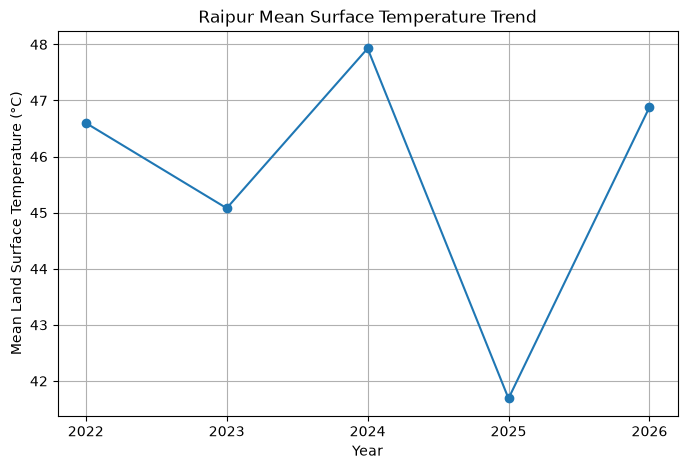

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    yearly_stats["Year"],
    yearly_stats["mean_LST"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean Land Surface Temperature (°C)")
plt.title(
    "Raipur Mean Surface Temperature Trend"
)

plt.xticks(
    yearly_stats["Year"]
)

plt.grid(True)

plt.show()

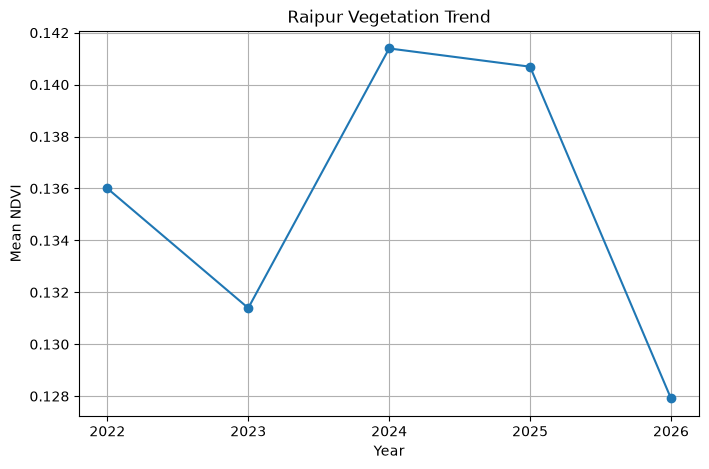

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    yearly_stats["Year"],
    yearly_stats["mean_NDVI"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean NDVI")
plt.title(
    "Raipur Vegetation Trend"
)

plt.xticks(
    yearly_stats["Year"]
)

plt.grid(True)

plt.show()

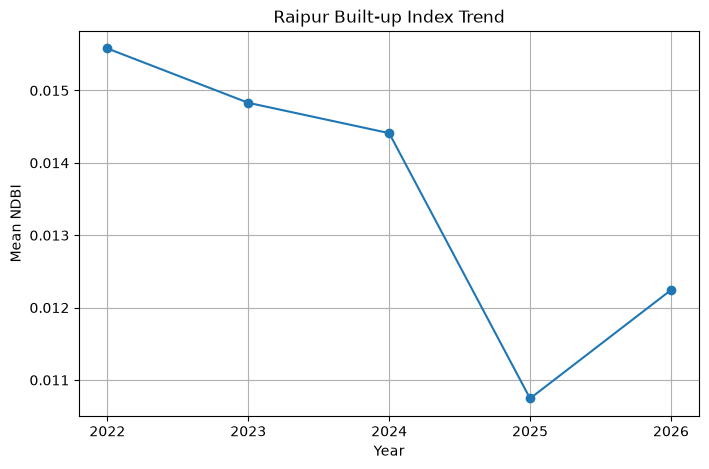

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    yearly_stats["Year"],
    yearly_stats["mean_NDBI"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Mean NDBI")
plt.title(
    "Raipur Built-up Index Trend"
)

plt.xticks(
    yearly_stats["Year"]
)

plt.grid(True)

plt.show()

In [26]:
output_path = (
    "../../data/processed/"
    "raipur_5year_processed.csv"
)

df.to_csv(
    output_path,
    index=False
)

print(
    f"Saved processed dataset to: {output_path}"
)

Saved processed dataset to: ../../data/processed/raipur_5year_processed.csv


In [27]:
print(df.shape)
print(yearly_stats)

(12500, 16)
   Year   mean_LST    min_LST    max_LST  mean_NDVI  mean_NDBI  mean_NDWI
0  2022  46.599727  33.451484  55.190091   0.136003   0.015581  -0.163215
1  2023  45.079656  30.758084  55.234526   0.131394   0.014830  -0.154045
2  2024  47.927810  34.605066  61.361326   0.141394   0.014411  -0.160540
3  2025  41.688571  30.448754  52.862420   0.140691   0.010745  -0.163526
4  2026  46.879713  34.165850  53.920297   0.127912   0.012243  -0.153232


In [28]:
print(
    df.groupby("Year")["LST"].mean()
)

Year
2022    46.599727
2023    45.079656
2024    47.927810
2025    41.688571
2026    46.879713
Name: LST, dtype: float64
